In [90]:
import pandas as pd
import numpy as np

norm = np.random.normal(0, 1, 200) # 0 mean, 1 std, 100 points
print(f"mean: {norm.mean()}, std: {norm.std()}")

mean: -0.009705431648003375, std: 1.0508005342889888


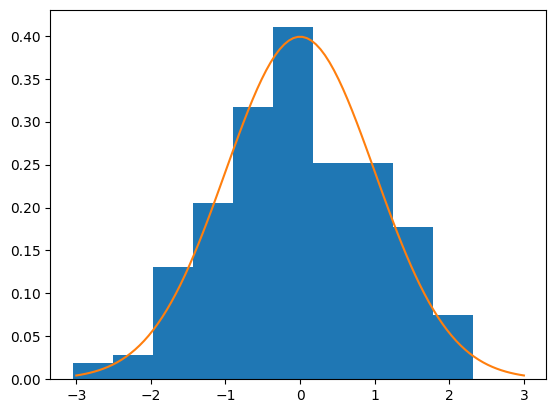

In [91]:
%matplotlib inline
from matplotlib import pyplot as plt


# make points for true normal distribution
def gauss_points(mean: float, std: float, count = 100) -> "dict[np.ArrayLike]":
    # mean -+ 3std are 2% and 98% quantiles of normal distribution respectively
    xs = np.linspace(mean - 3 * std, mean + 3 * std, num=count)
    ys = [1.0 / (np.sqrt(2 * np.pi) * std) * np.exp(((x - mean) / std)**2 / 2 * -1) for x in xs]
    return xs, ys

def plot_theor_and_real_dist(arr: "np.ArrayLike", plot_distr: callable, bins = 10):
    plt.hist(arr, bins = bins, density=True)
    xs, ys = plot_distr()
    plt.plot(xs, ys)
plot_theor_and_real_dist(norm, lambda: gauss_points(0, 1))

mean of means: -0.012949667905863807


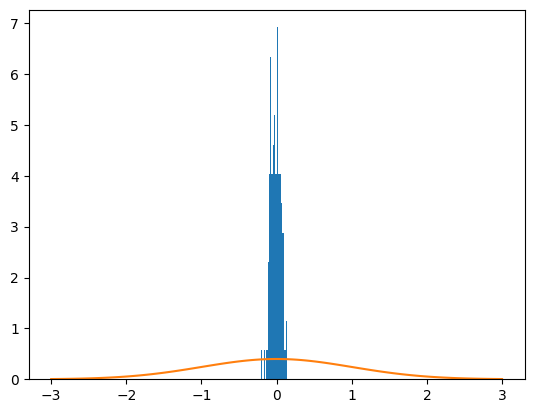

In [108]:
def bootstrap(arr: "np.ArrayLike", steps = 3, flatten = True, rand_state = 42):
    res = []
    if flatten:
        res.extend(arr)
        res.extend(np.random.choice(arr, len(arr) * steps, replace=True))
        
    else:
        res.append(arr)
        res.extend([np.random.choice(arr, len(arr), replace=True) for i in range(steps)])
    return res

norms_bootstrapped = np.array(bootstrap(norm, steps = 100, flatten=False))
means_bootstrapped = [np.mean(x) for x in norms_bootstrapped]
print(f"mean of means: {np.array(means_bootstrapped).mean()}")
plot_theor_and_real_dist(means_bootstrapped, lambda: gauss_points(0, 1), bins=20)

## Variance

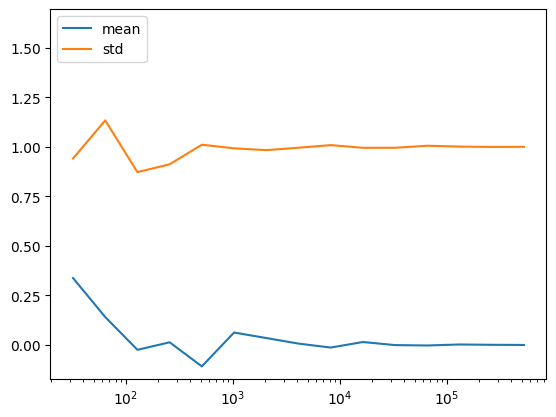

In [111]:
def mean_std_convergence(create_dist_callback: callable, logspace: tuple[int] = (5, 20), separate = False):
    """plots series of means and stds for series of array whith logariphmically increasing number of samples
       create_dist_callback - a callback, taking one int argument to draw a corresponding number of samples from distribution
       logspace - bottom and top borders of each array size on logarithmic scale
       separate (def. False) - draw mean and std graphs on separate axis"""
    means = []; stds = []
    scales = [2**x for x in range(*logspace)]
    for num_samples in scales:
        a = create_dist_callback(num_samples)
        means.append(a.mean()); stds.append(a.std())
    if not separate:
        plt.semilogx(scales, means, label = "mean")
        plt.semilogx(scales, stds, label = "std")
        plt.legend(loc='upper left')
        ybottom,ytop = plt.ylim()
        plt.ylim((ybottom,ytop + 0.5))  # to add space for legend
    else:
        fig, axs = plt.subplots(2, 1, sharex=True)
        axs[0].semilogx(scales, means, label = "mean")
        axs[0].set_title("mean")
        axs[1].semilogx(scales, stds, label = "std")
        axs[1].set_title("std")

mean_std_convergence(lambda x: np.random.normal(0, 1, size = x))

Cauchy distrubution is an example of a distribution that doesn't have defined mean and std, so for as much samples as we would take from it, the sequence of these parameters won't converge to any value. First, let's see how it looks:

mean: -0.543342661699709, std: 12.465786110252083


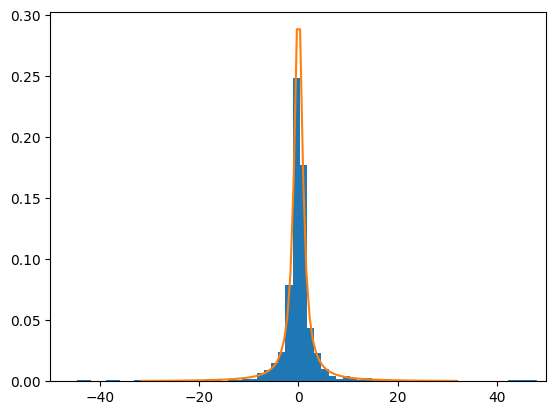

In [135]:
def cauchy_pdf_curve(med, mad, points = 100):
    q1 = med + mad * np.tan(np.pi * (0.01 - 0.5))
    q99 = med + mad * np.tan(np.pi * (0.99 - 0.5))
    xs = np.linspace(q1, q99, num=points)
    ys = [1.0 / (np.pi*mad*(1 + ((x-med)/mad)**2)) for x in xs]
    return xs, ys

x1 = np.random.normal(loc = 0, size = 1000)
cauchy = np.array([np.tan(np.pi*(x - 1/2)) for x in x1])

plot_theor_and_real_dist(cauchy, lambda: cauchy_pdf_curve(0, 1), bins = 200)
#cauchy distribution can with relatively hight probability throw a number wherever it wants, so I limit the scale here,
#you can rerun this cell if the samples don't seem to follow the distribution, with 1000 size they normally will, but just in case
plt.xlim(-50, 50)
print(f"mean: {cauchy.mean()}, std: {cauchy.std()}")

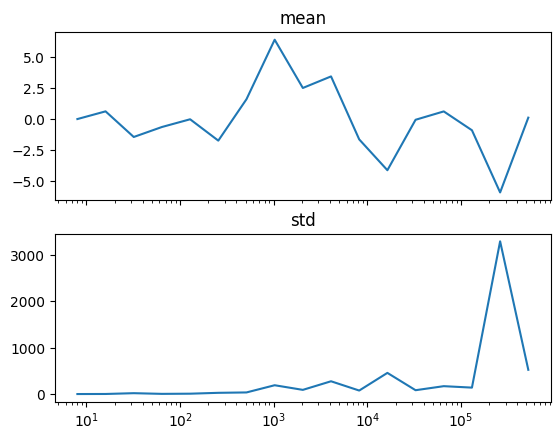

In [137]:
def draw_cauchy_samples(size: int):
    x1 = np.random.normal(loc = 0, size = size)
    cauchy = np.array([np.tan(np.pi*(x - 1/2)) for x in x1])
    return cauchy
mean_std_convergence(draw_cauchy_samples, (3,20), separate=True)